In [1]:
from prepro import process_single_image, preprocess_pipeline
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [2]:
preprocess_pipeline(
    denoising_method="gaussian",
    masking=True,
    cropping=True,
    clahe=True,
    target_size=256
)

Dataset source: /home/cepa/DST/docker_covid/data/raw/COVID-19_Radiography_Dataset
Dataset de sortie: /home/cepa/DST/docker_covid/data/processed/256x256_L_masked_cropped_clahe
Taille cible: 256x256
Mode couleur: L (grayscale) uniquement (radiographies)
Avec masquage: True
Avec recadrage: True
Avec CLAHE: True
Avec denoising: gaussian
Classes: ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']


Traitement de la classe: COVID
Nombre d'images trouvées: 3616


Processing COVID: 100%|██████████| 3616/3616 [00:24<00:00, 149.73it/s]


✓ COVID: 3616 images créées

Traitement de la classe: Normal
Nombre d'images trouvées: 10192


Processing Normal: 100%|██████████| 10192/10192 [01:07<00:00, 150.13it/s]


✓ Normal: 10192 images créées

Traitement de la classe: Lung_Opacity
Nombre d'images trouvées: 6012


Processing Lung_Opacity: 100%|██████████| 6012/6012 [00:41<00:00, 146.00it/s]


✓ Lung_Opacity: 6012 images créées

Traitement de la classe: Viral Pneumonia
Nombre d'images trouvées: 1345


Processing Viral Pneumonia: 100%|██████████| 1345/1345 [00:09<00:00, 145.44it/s]

✓ Viral Pneumonia: 1345 images créées

RÉSUMÉ
Total d'images traitées: 21165
Erreurs: 0

Nombre d'images par classe dans le nouveau dataset:
  COVID: 3616
  Normal: 10192
  Lung_Opacity: 6012
  Viral Pneumonia: 1345

✓ Dataset créé avec succès dans: /home/cepa/DST/docker_covid/data/processed/256x256_L_masked_cropped_clahe


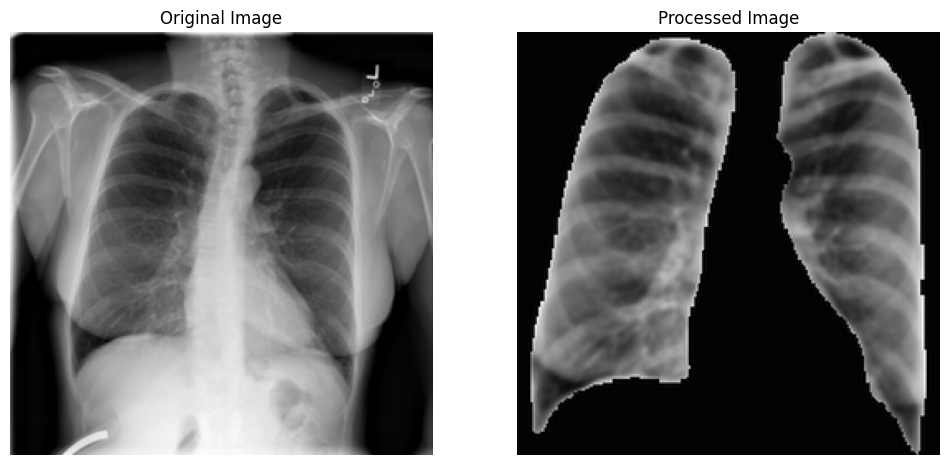

In [2]:
img_pth = Path("/home/cepa/DST/docker_covid/data/raw/COVID-19_Radiography_Dataset/Normal/images/Normal-1407.png")
mask_pth = Path("/home/cepa/DST/docker_covid/data/raw/COVID-19_Radiography_Dataset/Normal/masks/Normal-1407.png")

denoising_method = "gaussian"
clahe_processor = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
target_size = 256
cropping = True

masked_img = process_single_image(
    img_path=img_pth,
    mask_path=mask_pth,
    cropping=cropping,
    denoising_method=denoising_method,
    clahe_processor=clahe_processor,
    target_size=target_size
)

# masked_img is a numpy array

# We plot the original image and the processed image side by side

# Load original image for comparison
original_img = cv2.imread(str(img_pth), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(original_img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Processed Image")
plt.imshow(masked_img, cmap='gray')
plt.axis('off')
plt.show()